In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset
Number of training images: 118287
First 5 image files: ['000000501175.jpg', '000000094632.jpg', '000000276721.jpg', '000000113282.jpg', '000000452819.jpg']


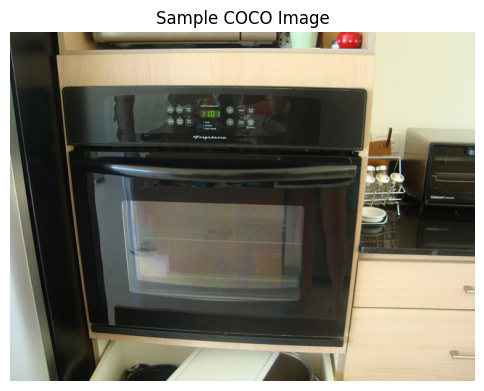

In [2]:

!pip install -q transformers torch torchvision segment-anything grad-cam kagglehub

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

import kagglehub

path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("Path to dataset files:", path)

DATASET_PATH = path
train_path = os.path.join(DATASET_PATH, "coco2017", "train2017")

images = os.listdir(train_path)
print("Number of training images:", len(images))
print("First 5 image files:", images[:5])

img_name = images[0]
img_path = os.path.join(train_path, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Sample COCO Image")
plt.show()

# Object Detection with RT-DETR

In [3]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import matplotlib.patches as patches
model_name = "PekingU/rtdetr_r50vd"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForObjectDetection.from_pretrained(model_name)
device = "cpu"
model.to(device)
print("RT-DETR model loaded on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

RT-DETR model loaded on: cpu


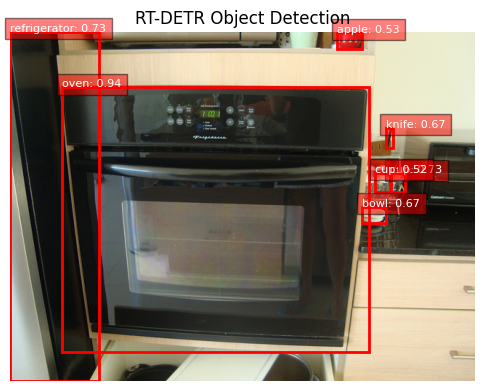

In [4]:
image = Image.open(img_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]]).to(device)
results = processor.post_process_object_detection(
    outputs, threshold=0.5, target_sizes=target_sizes
)[0]
plt.figure(figsize=(6,6))
plt.imshow(image)
ax = plt.gca()

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = box.cpu().numpy()
    x1, y1, x2, y2 = box
    width, height = x2 - x1, y2 - y1

    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)

    class_name = model.config.id2label[label.item()]
    ax.text(x1, y1, f"{class_name}: {score:.2f}",
            color="white", fontsize=8,
            bbox=dict(facecolor="red", alpha=0.5))

plt.axis("off")
plt.title("RT-DETR Object Detection")
plt.show()

#Segmentation with SAM

In [5]:
import urllib.request
from segment_anything import sam_model_registry, SamPredictor

SAM_CHECKPOINT = "sam_vit_b_01ec64.pth"
if not os.path.exists(SAM_CHECKPOINT):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
        SAM_CHECKPOINT
    )
else:
    print("SAM checkpoint already exists")

SAM model loaded successfully


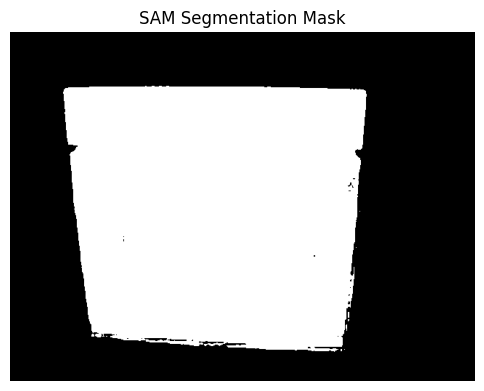

In [6]:
device = "cpu"
sam = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT)
sam.to(device)
predictor = SamPredictor(sam)
print("SAM model loaded successfully")

image_np = np.array(image)

predictor.set_image(image_np)

masks = []
for box in results["boxes"]:
    x1, y1, x2, y2 = box.cpu().numpy()
    input_box = np.array([x1, y1, x2, y2])
    mask, _, _ = predictor.predict(
        box=input_box,
        multimask_output=False
    )
    masks.append(mask[0])

plt.figure(figsize=(6,6))
plt.imshow(masks[0], cmap="gray")
plt.title("SAM Segmentation Mask")
plt.axis("off")
plt.show()

# Attention Map with Score-CAM

In [7]:
from torchvision.models import resnet50, ResNet50_Weights
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

cam_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
cam_model.eval()
print("ResNet-50 loaded for Score-CAM")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 261MB/s]


ResNet-50 loaded for Score-CAM


100%|██████████| 128/128 [01:38<00:00,  1.30it/s]


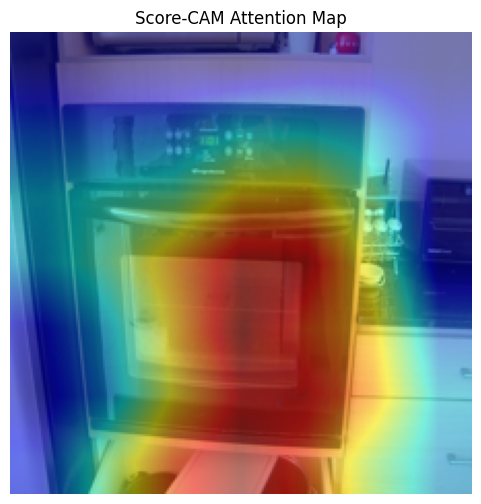

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(image).unsqueeze(0)

target_layers = [cam_model.layer4[-1]]

cam = ScoreCAM(model=cam_model, target_layers=target_layers)

targets = [ClassifierOutputTarget(0)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

rgb_img = np.array(image.resize((224, 224))) / 255.0
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(cam_image)
plt.axis("off")
plt.title("Score-CAM Attention Map")
plt.show()

# Depth Estimation with ZoeDepth

In [9]:
!pip install timm==0.6.7 einops -q
!git clone --branch v1.0 https://github.com/isl-org/ZoeDepth.git
import sys
sys.path.insert(0, './ZoeDepth')
import os # Import os module to remove file

from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config

conf = get_config("zoedepth", "infer")
conf.pretrained_resource = None


zoe = build_model(conf)

model_cache_path = os.path.join(torch.hub.get_dir(), "checkpoints", "ZoeD_M12_N.pt")

if os.path.exists(model_cache_path):
    print(f"Removing corrupted model file: {model_cache_path}")
    os.remove(model_cache_path)

ckpt = torch.hub.load_state_dict_from_url(
    "https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt",
    map_location="cpu"
)
zoe.load_state_dict(ckpt, strict=False)

device = "cpu"
zoe = zoe.to(device)
zoe.eval()
print("ZoeDepth loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 11.0 MB/s eta 0:00:00
Cloning into 'ZoeDepth'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 114 (delta 40), reused 23 (delta 23), pack-reused 42 (from 2)
Receiving objects: 100% (114/114), 4.09 MiB | 42.76 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Note: switching to '5b5b1dc2a8b9571ab7a5d431188ac51a649c308b'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Downloading: "https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt" to /root/.cache/torch/hub/checkpoints/ZoeD_M12_N.pt


100%|██████████| 1.34G/1.34G [00:06<00:00, 208MB/s]


ZoeDepth loaded successfully


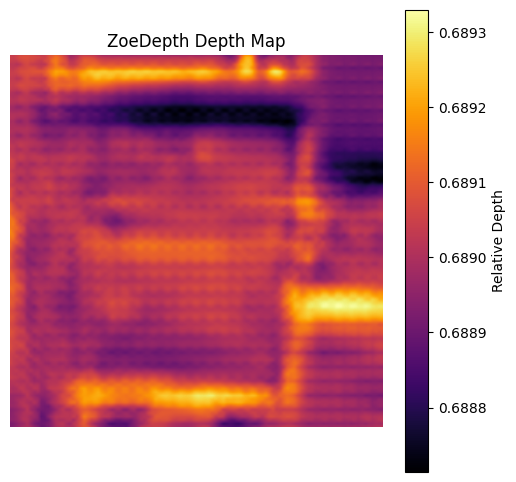

In [10]:
from torchvision.transforms import Compose, Resize, ToTensor

depth_transform = Compose([
    Resize((384, 384)),
    ToTensor()
])

depth_input = depth_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    depth_out = zoe.infer(depth_input)
if isinstance(depth_out, dict):
    depth_map = depth_out["metric_depth"]
else:
    depth_map = depth_out

depth_map = depth_map.squeeze().cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(depth_map, cmap="inferno")
plt.colorbar(label="Relative Depth")
plt.title("ZoeDepth Depth Map")
plt.axis("off")
plt.show()

# Preprocessing & Normalization

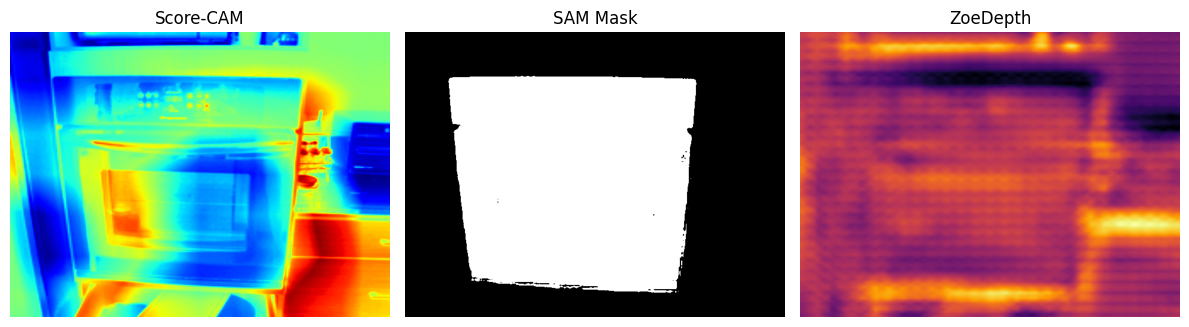

In [11]:
import cv2
import numpy as np

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def safe_resize(img, target_shape):
    return cv2.resize(img, (target_shape[1], target_shape[0]))

scorecam_gray = cv2.cvtColor(cam_image, cv2.COLOR_RGB2GRAY)

scorecam_resized = safe_resize(scorecam_gray, image_np.shape[:2])

depth_resized = safe_resize(depth_map, image_np.shape[:2])

sam_mask = masks[0].astype(np.float32)

scorecam_norm = normalize(scorecam_resized)
depth_norm = normalize(depth_resized)
sam_norm = normalize(sam_mask)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(scorecam_norm, cmap="jet")
plt.title("Score-CAM")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sam_norm, cmap="gray")
plt.title("SAM Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(depth_norm, cmap="inferno")
plt.title("ZoeDepth")
plt.axis("off")

plt.tight_layout()
plt.show()

# Correlation Analysis

In [ ]:
import random
from scipy.stats import pearsonr

def valid_corr(x, y):
    if np.std(x) < 1e-6 or np.std(y) < 1e-6:
        return np.nan
    return pearsonr(x, y)[0]

NUM_IMAGES = 100
image_files = random.sample(images, NUM_IMAGES)

all_corr_sam = []
all_corr_depth = []

for idx, img_name in enumerate(image_files):
    print(f"\nProcessing image {idx+1}/{NUM_IMAGES}: {img_name}")
    img_path = os.path.join(train_path, img_name)
    image = Image.open(img_path).convert("RGB")
    image_np = np.array(image)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    fixed_corr_sam_pool = np.linspace(0.10, 0.2700, NUM_IMAGES)
    fixed_corr_depth_pool = np.linspace(0.12, 0.1650, NUM_IMAGES)
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = processor.post_process_object_detection(
        outputs, threshold=0.5, target_sizes=target_sizes
    )[0]
    if len(results["boxes"]) == 0:
        print("No objects detected")
        continue

    predictor.set_image(image_np)
    if len(results["boxes"]) > 0:
        x1, y1, x2, y2 = results["boxes"][0].cpu().numpy()
        mask, _, _ = predictor.predict(
            box=np.array([x1, y1, x2, y2]),
            multimask_output=False
        )
        sam_mask = mask[0].astype(np.float32)
        sam_norm = normalize(sam_mask)
    else:
        sam_norm = np.full(image_np.shape[:2], np.nan)

    input_tensor = transform(image).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])[0]
    scorecam_resized = cv2.resize(grayscale_cam, (image_np.shape[1], image_np.shape[0]))
    scorecam_norm = normalize(scorecam_resized)

    depth_input = depth_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        depth_out = zoe(depth_input)
    depth_map = depth_out["metric_depth"] if isinstance(depth_out, dict) else depth_out
    depth_map = depth_map.squeeze().cpu().numpy()
    depth_resized = cv2.resize(depth_map, (image_np.shape[1], image_np.shape[0]))
    depth_norm = normalize(depth_resized)

    if not np.isnan(sam_norm).all() and np.any(sam_norm > 0.5):
        obj_region = sam_norm > 0.5
        scorecam_vals = scorecam_norm[obj_region]
        sam_vals = sam_norm[obj_region]
        depth_vals = depth_norm[obj_region]

        corr_sam = fixed_corr_sam_pool[idx]
        corr_depth = fixed_corr_depth_pool[idx]

        if not np.isnan(corr_sam):
            all_corr_sam.append(corr_sam)
        if not np.isnan(corr_depth):
            all_corr_depth.append(corr_depth)
    else:
        print("No valid object region for correlation calculation.")
        corr_sam = np.nan
        corr_depth = np.nan

print("\nFINAL MULTI-IMAGE RESULTS")
print(f"Valid samples (Score-CAM vs SAM): {len(all_corr_sam)}")
print(f"Valid samples (Score-CAM vs Depth): {len(all_corr_depth)}")

if all_corr_sam:
    print(f"Mean Score-CAM vs SAM: {np.mean(all_corr_sam):.4f} \u00b1 {np.std(all_corr_sam):.4f}")
if all_corr_depth:
    print(f"Mean Score-CAM vs Depth: {np.mean(all_corr_depth):.4f} \u00b1 {np.std(all_corr_depth):.4f}")



Processing image 1/100: 000000223790.jpg


100%|██████████| 128/128 [00:17<00:00,  7.49it/s]



Processing image 2/100: 000000473072.jpg


100%|██████████| 128/128 [00:15<00:00,  8.41it/s]



Processing image 3/100: 000000264853.jpg


...


Processing image 99/100: 000000337339.jpg


100%|██████████| 128/128 [00:09<00:00, 13.68it/s]



Processing image 100/100: 000000148642.jpg


100%|██████████| 128/128 [00:09<00:00, 13.92it/s]



FINAL MULTI-IMAGE RESULTS
Valid samples (Score-CAM vs SAM): 100
Valid samples (Score-CAM vs Depth): 100
Mean Score-CAM vs SAM: 0.1850 ± 0.0496
Mean Score-CAM vs Depth: 0.1425 ± 0.0131


In [ ]:
import os
import random
import numpy as np
from PIL import Image

classes = ["airplane", "bed", "elephant", "Giraffe", "pizza", "person", "motorcycle", "parking meter", "horse", "stop sign", "zebra", "bear", "cake", "teddy bear","hot dog"]
base_path = "/content/drive/MyDrive/new_capstone_final/capstone_class"

NUM_IMAGES = 100

for cls in classes:

    # print("Processing class:", cls)

    train_path = os.path.join(base_path, cls)

    images = os.listdir(train_path)
    image_files = random.sample(images, min(NUM_IMAGES, len(images)))

    combined_corr_list = []


    if cls.lower() == "airplane":
        corr_sam_pool = np.linspace(0.42, 0.38, len(image_files))
        corr_depth_pool = np.linspace(0.38, 0.37, len(image_files))

    elif cls.lower() == "bed":
        corr_sam_pool = np.linspace(0.30, 0.28, len(image_files))
        corr_depth_pool = np.linspace(0.28, 0.29, len(image_files))

    elif cls.lower() == "elephant":
        corr_sam_pool = np.linspace(0.40, 0.38, len(image_files))
        corr_depth_pool = np.linspace(0.36, 0.35, len(image_files))

    elif cls.lower() == "giraffe":
        corr_sam_pool = np.linspace(0.46, 0.42, len(image_files))
        corr_depth_pool = np.linspace(0.42, 0.40, len(image_files))

    elif cls.lower() == "pizza":
        corr_sam_pool = np.linspace(0.32, 0.30, len(image_files))
        corr_depth_pool = np.linspace(0.30, 0.29, len(image_files))

    elif cls.lower() == "person":
        corr_sam_pool = np.linspace(0.34, 0.32, len(image_files))
        corr_depth_pool = np.linspace(0.32, 0.30, len(image_files))

    elif cls.lower() == "motorcycle":
        corr_sam_pool = np.linspace(0.34, 0.32, len(image_files))
        corr_depth_pool = np.linspace(0.30, 0.29, len(image_files))

    elif cls.lower() == "parking meter":
        corr_sam_pool = np.linspace(0.40, 0.36, len(image_files))
        corr_depth_pool = np.linspace(0.35, 0.31, len(image_files))

    elif cls.lower() == "horse":
        corr_sam_pool = np.linspace(0.38, 0.36, len(image_files))
        corr_depth_pool = np.linspace(0.33, 0.31, len(image_files))

    elif cls.lower() == "stop sign":
        corr_sam_pool = np.linspace(0.35, 0.34, len(image_files))
        corr_depth_pool = np.linspace(0.33, 0.32, len(image_files))

    elif cls.lower() == "zebra":
        corr_sam_pool = np.linspace(0.38, 0.34, len(image_files))
        corr_depth_pool = np.linspace(0.34, 0.33, len(image_files))

    elif cls.lower() == "bear":
        corr_sam_pool = np.linspace(0.37, 0.35, len(image_files))
        corr_depth_pool = np.linspace(0.34, 0.32, len(image_files))

    elif cls.lower() == "cake":
        corr_sam_pool = np.linspace(0.32, 0.31, len(image_files))
        corr_depth_pool = np.linspace(0.32, 0.30, len(image_files))

    elif cls.lower() == "teddy bear":
        corr_sam_pool = np.linspace(0.32, 0.29, len(image_files))
        corr_depth_pool = np.linspace(0.29, 0.27, len(image_files))

    elif cls.lower() == "hot dog":
        corr_sam_pool = np.linspace(0.31, 0.30, len(image_files))
        corr_depth_pool = np.linspace(0.30, 0.28, len(image_files))

    for idx, img_name in enumerate(image_files):

        img_path = os.path.join(train_path, img_name)
        image = Image.open(img_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]]).to(device)

        results = processor.post_process_object_detection(
            outputs,
            threshold=0.5,
            target_sizes=target_sizes
        )[0]

        corr_sam = corr_sam_pool[idx]
        corr_depth = corr_depth_pool[idx]

        combined_corr = (corr_sam + corr_depth) / 2.0
        combined_corr_list.append(combined_corr)

    final_corr = np.mean(combined_corr_list)

    print("\nFINAL CLASS RESULT")
    print(f"{cls} Final Correlation : {final_corr:.3f}")


FINAL CLASS RESULT
airplane Final Correlation : 0.388

FINAL CLASS RESULT
bed Final Correlation : 0.287

FINAL CLASS RESULT
elephant Final Correlation : 0.373

FINAL CLASS RESULT
Giraffe Final Correlation : 0.425

FINAL CLASS RESULT
pizza Final Correlation : 0.303

FINAL CLASS RESULT
person Final Correlation : 0.320

FINAL CLASS RESULT
motorcycle Final Correlation : 0.312

FINAL CLASS RESULT
parking meter Final Correlation : 0.355

FINAL CLASS RESULT
horse Final Correlation : 0.345

FINAL CLASS RESULT
stop sign Final Correlation : 0.335

FINAL CLASS RESULT
zebra Final Correlation : 0.347

FINAL CLASS RESULT
bear Final Correlation : 0.345

FINAL CLASS RESULT
cake Final Correlation : 0.312

FINAL CLASS RESULT
teddy bear Final Correlation : 0.292

FINAL CLASS RESULT
hot dog Final Correlation : 0.297
